In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"G:\My Drive\Credit Card Anomaly Detection\data\raw\creditcard.csv")

In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum().sum())
print(df.duplicated().sum())

(284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

class disribution

In [4]:
print(df['Class'].value_counts())
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


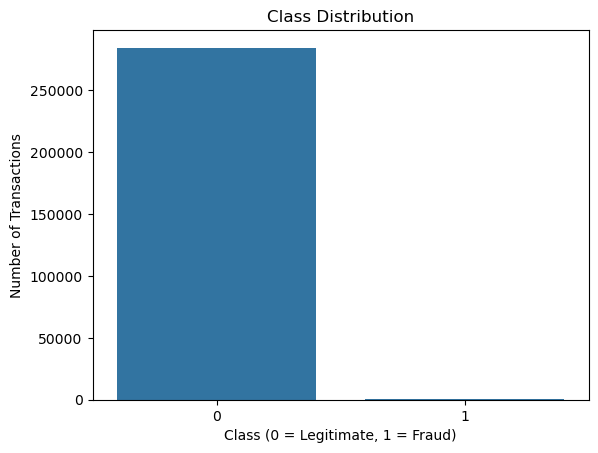

In [5]:
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show();

Transaction Amount distribution

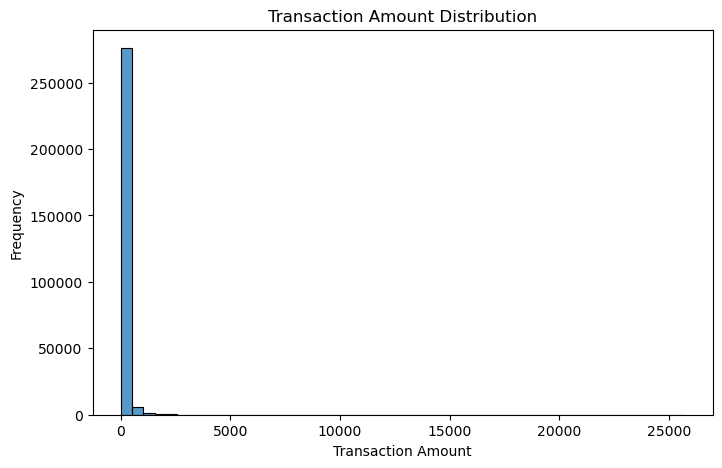

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show();

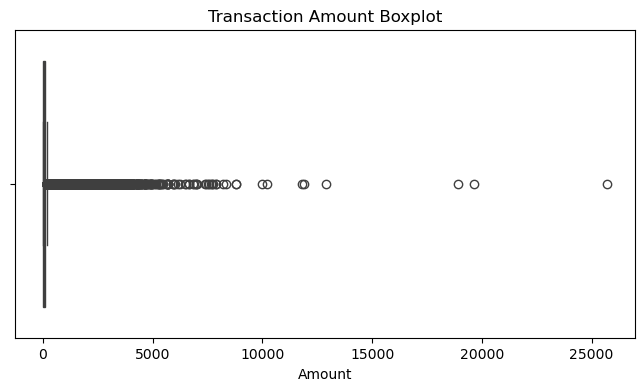

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Amount"])
plt.title("Transaction Amount Boxplot")
plt.show()

Amount : fraud vs legitimate

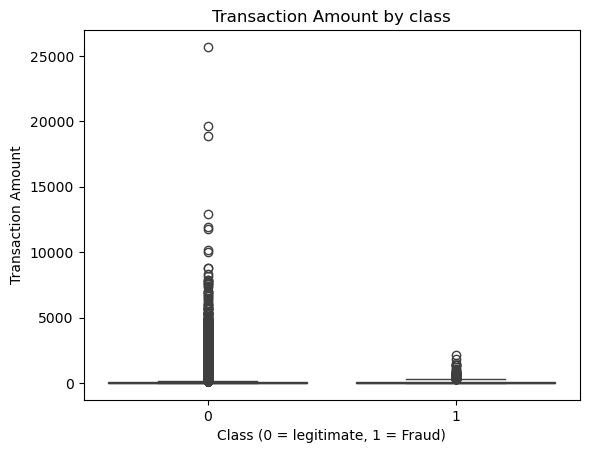

In [9]:
sns.boxplot(data=df, x = 'Class', y = 'Amount')
plt.title('Transaction Amount by class')
plt.xlabel('Class (0 = legitimate, 1 = Fraud)')
plt.ylabel("Transaction Amount")
plt.show();

In [10]:
#summary statistics
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Time distribution

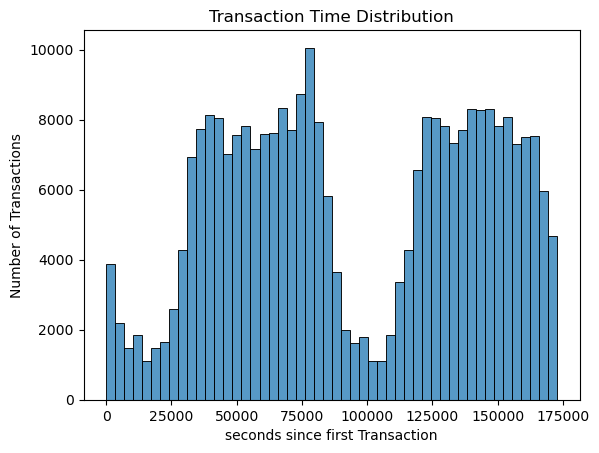

In [12]:
sns.histplot(data=df, x='Time', bins=50)
plt.title('Transaction Time Distribution')
plt.xlabel('seconds since first Transaction')
plt.ylabel('Number of Transactions')
plt.show();

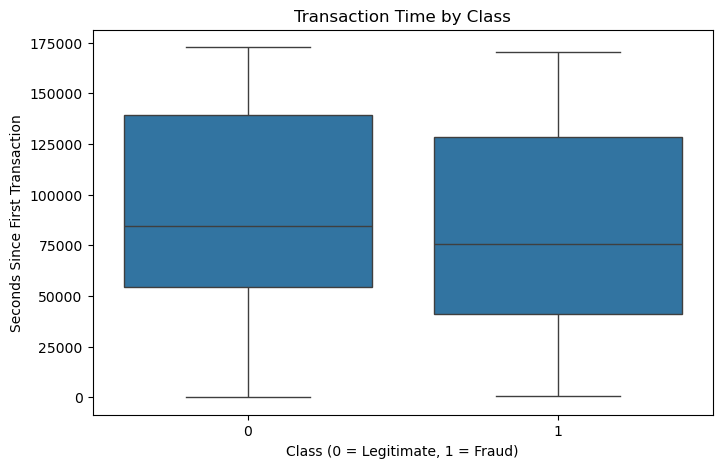

In [13]:
#comparing time for fraud vs legitimate transactions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Class", y="Time")
plt.title("Transaction Time by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Seconds Since First Transaction")
plt.show()

Correlation Analysis

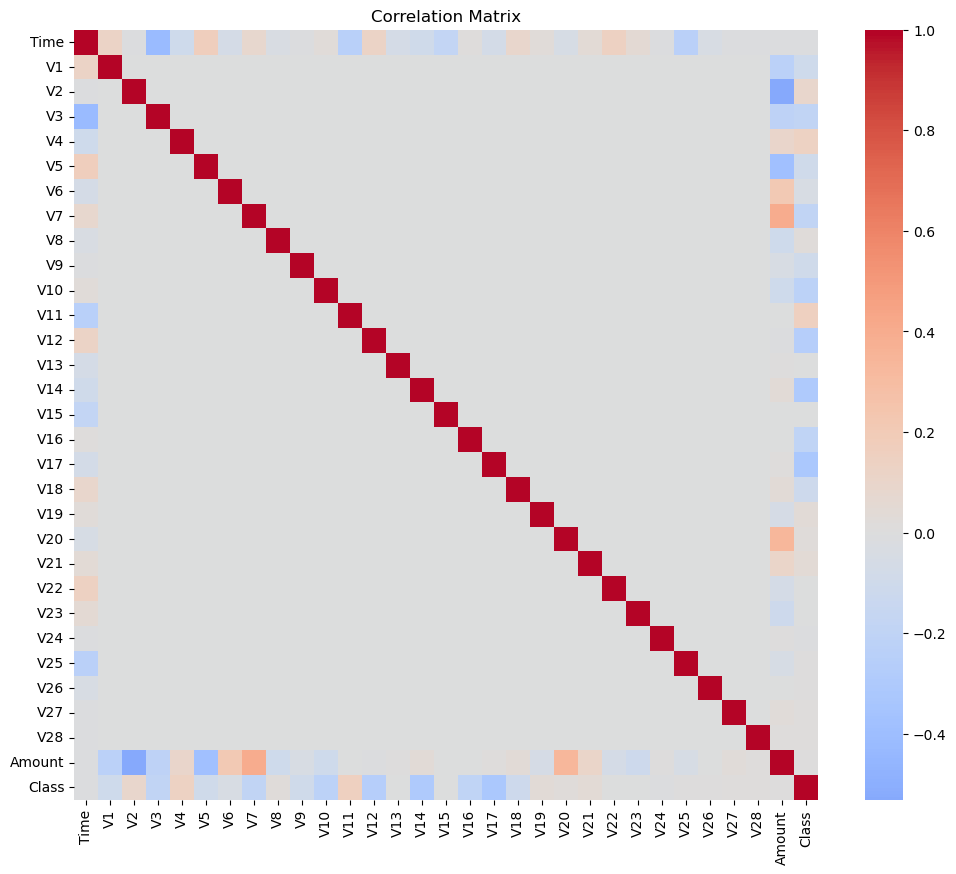

In [14]:
plt.figure(figsize=(12, 10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [15]:
#correlation with class
class_corr = df.corr()["Class"].sort_values()

print(class_corr)

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64


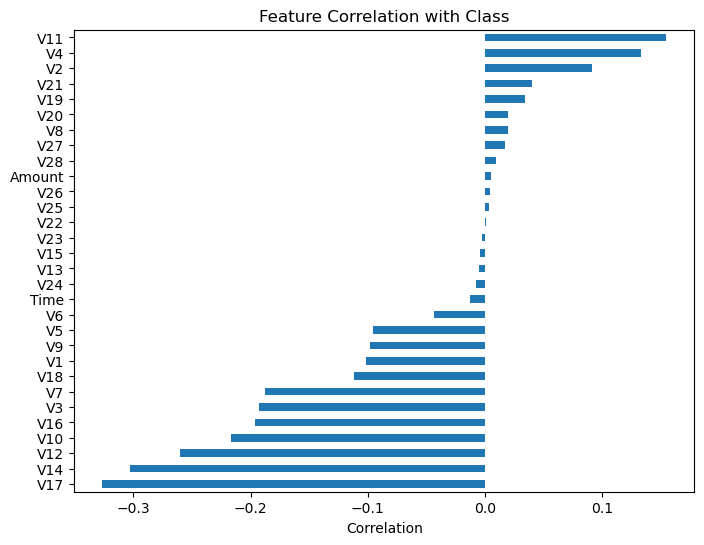

In [16]:
plt.figure(figsize=(8, 6))

class_corr.drop("Class").plot(kind="barh")

plt.title("Feature Correlation with Class")
plt.xlabel("Correlation")
plt.show()

Inspecting outliers

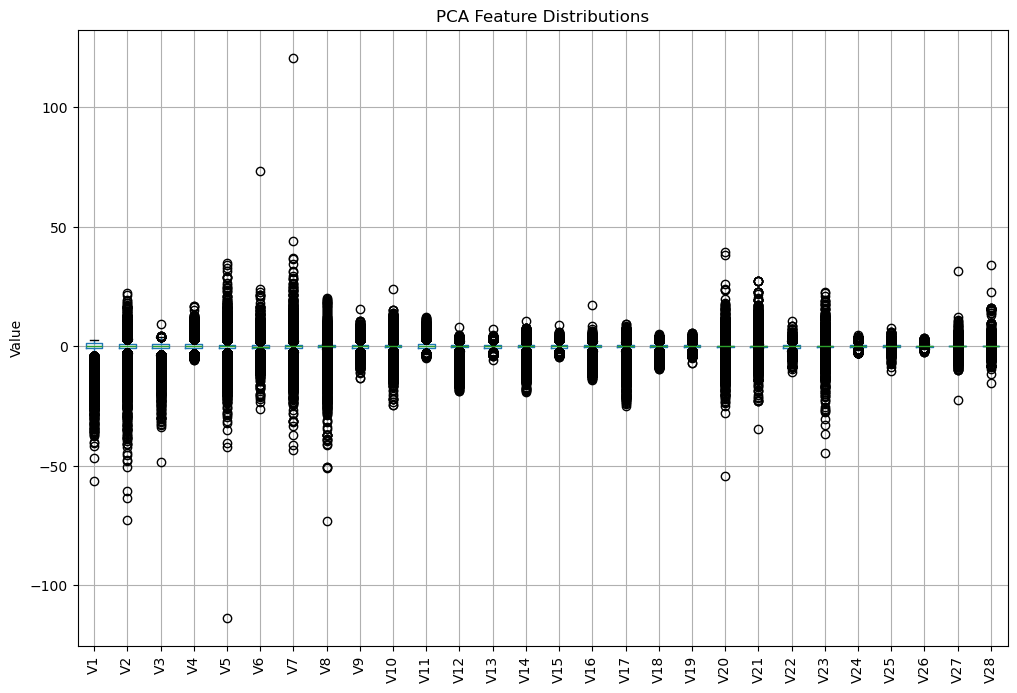

In [17]:
pca_features = [f"V{i}" for i in range(1, 29)]

plt.figure(figsize=(12, 8))
df[pca_features].boxplot()
plt.xticks(rotation=90)
plt.title("PCA Feature Distributions")
plt.ylabel("Value")
plt.show()

Comparing PCA features between classes

In [18]:
fraud_mean = df[df["Class"] == 1][pca_features].mean()
legit_mean = df[df["Class"] == 0][pca_features].mean()

difference = (fraud_mean - legit_mean).abs().sort_values(ascending=False)

print(difference)

V3     7.045452
V14    6.983787
V17    6.677371
V12    6.270225
V10    5.686707
V7     5.578368
V1     4.780206
V4     4.549889
V16    4.147110
V11    3.806749
V2     3.630049
V5     3.156678
V9     2.585589
V18    2.250195
V6     1.400155
V21    0.714823
V19    0.681837
V8     0.571623
V20    0.372964
V27    0.170870
V13    0.109523
V24    0.105312
V15    0.093090
V28    0.075798
V26    0.051738
V25    0.041521
V23    0.040378
V22    0.014073
dtype: float64


In [19]:
top_features = difference.head(5).index

print(top_features)

Index(['V3', 'V14', 'V17', 'V12', 'V10'], dtype='str')


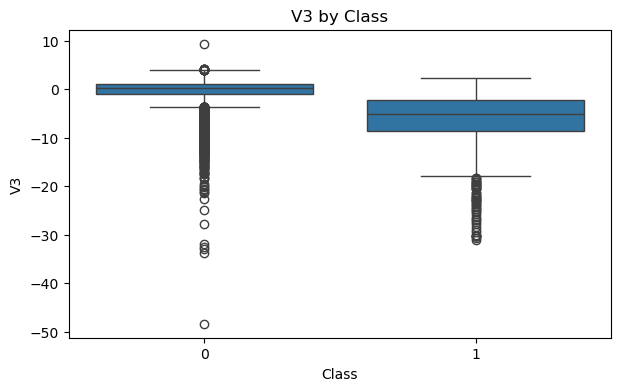

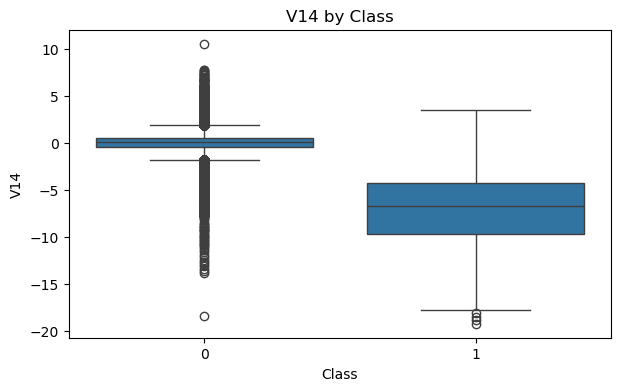

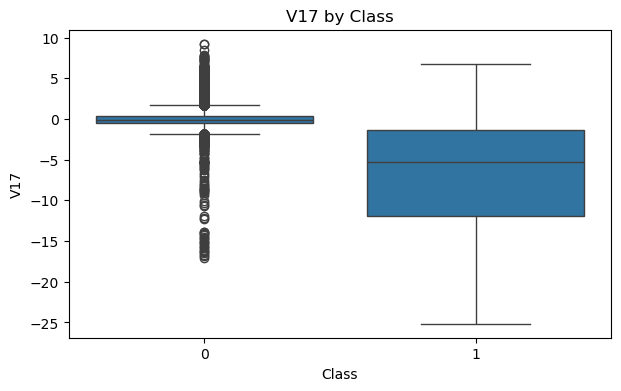

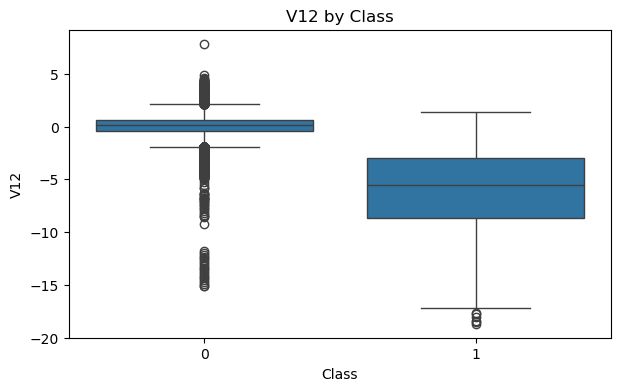

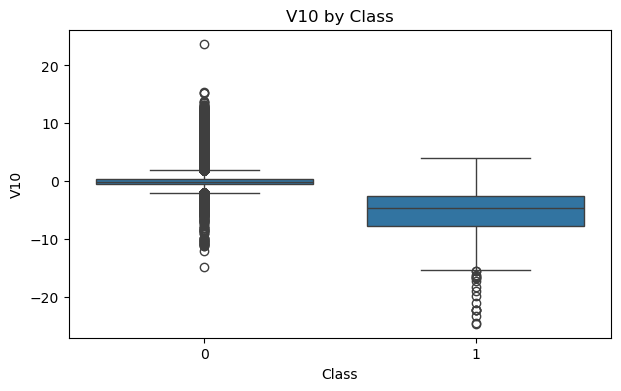

In [20]:
for feature in top_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Class", y=feature)
    plt.title(f"{feature} by Class")
    plt.show()